In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchaudio
from torchaudio.transforms import Resample

import matplotlib.pyplot as plt

In [2]:
#! pip install soundata
import soundata
from IPython.display import Audio
from sqlalchemy import all_

dataset = soundata.initialize('urbansound8k')
# dataset.download()  # download the dataset
# dataset.validate()  # validate that all the expected files are there

example_clip = dataset.choice_clip()  # choose a random example clip
print(example_clip)  # see the available data

audio_signal, sample_rate = example_clip.audio
Audio(data=audio_signal, rate=sample_rate)

# Build index → class name mapping
index_to_class = {}
for clip_id in dataset.clip_ids:
    clip = dataset.clip(clip_id)
    class_id = clip.class_id
    class_name = clip.class_label
    index_to_class[class_id] = class_name

all_classes = list(index_to_class.values())

Clip(
  audio_path="/home/nitin/sound_datasets/urbansound8k/audio/fold10/28808-1-0-5.wav",
  clip_id="28808-1-0-5",
  audio: The clip's audio
            * np.ndarray - audio signal
            * float - sample rate,
  class_id: The clip's class id.
            * int - integer representation of the class label (0-9). See Dataset Info in the documentation for mapping,
  class_label: The clip's class label.
            * str - string class name: air_conditioner, car_horn, children_playing, dog_bark, drilling, engine_idling, gun_shot, jackhammer, siren, street_music,
  fold: The clip's fold.
            * int - fold number (1-10) to which this clip is allocated. Use these folds for cross validation,
  freesound_end_time: The clip's end time in Freesound.
            * float - end time in seconds of the clip in the original freesound recording,
  freesound_id: The clip's Freesound ID.
            * str - ID of the freesound.org recording from which this clip was taken,
  freesound_start_ti

In [3]:
import pandas as pd
from pathlib import Path

download_path = '/home/nitin/sound_datasets/urbansound8k'

# Read metadata file
metadata_file = download_path + '/metadata/UrbanSound8K.csv'
df = pd.read_csv(metadata_file)
df.head()

# Construct file path by concatenating fold and file name
df['relative_path'] = '/fold' + df['fold'].astype(str) + '/' + df['slice_file_name'].astype(str)

# Take relevant columns
df = df[['relative_path', 'classID']]
df.head()


,relative_path,classID
0,/fold5/100032-3-0-0.wav,3
1,/fold5/100263-2-0-117.wav,2
2,/fold5/100263-2-0-121.wav,2
3,/fold5/100263-2-0-126.wav,2
4,/fold5/100263-2-0-137.wav,2


In [4]:
from hmac import new
import math, random
from torchaudio import transforms
from IPython.display import Audio

class AudioUtil():
    def __init__(self):
        pass

    @staticmethod
    def open(audio_file):
        sig, sr = torchaudio.load(audio_file)
        return (sig, sr)

    @staticmethod
    def rechannel(aud, new_channel):
        sig, sr = aud

        if (sig.shape[0] == new_channel):
            # Nothing to do
            return aud

        if (new_channel == 1):
            # Convert from stereo to mono by selecting only the first channel
            resig = sig[:1, :]
        else:
            # Convert from mono to stereo by duplicating the first channel
            resig = torch.cat([sig, sig])

        return ((resig, sr))
    
    # ----------------------------
    # Since Resample applies to a single channel, we resample one channel at a time
    # ----------------------------
    @staticmethod
    def resample(aud, newsr):
        sig, sr = aud

        if (sr == newsr):
            # Nothing to do
            return aud

        num_channels = sig.shape[0]
        # Resample first channel
        resig = torchaudio.transforms.Resample(sr, newsr)(sig[:1,:])
        if (num_channels > 1):
            # Resample the second channel and merge both channels
            retwo = torchaudio.transforms.Resample(sr, newsr)(sig[1:,:])
            resig = torch.cat([resig, retwo])

        return ((resig, newsr))

    @staticmethod
    def pad_trunc(aud, max_ms):
        sig, sr = aud
        num_channels, sig_len = sig.shape
        max_len = sr//1000 * max_ms

        if sig_len > max_len:
            sig = sig[:,:max_len]
        elif sig_len < max_len:
            # Find length of padding to be inserted at the start and end of the signal
            pad_begin_len = random.randint(0, max_len - sig_len)
            pad_end_len = max_len - sig_len - pad_begin_len

            # Pad with 0s
            pad_begin = torch.zeros((num_channels, pad_begin_len))
            pad_end = torch.zeros((num_channels, pad_end_len))
            sig = torch.cat([pad_begin, sig, pad_end], 1)
        return (sig, sr)

    @staticmethod
    def time_shift(aud, shift_limit):
        sig, sr = aud
        _, sig_len = sig.shape
        shift_amount = int(random.random() * shift_limit * sig_len)
        return (sig.roll(shift_amount), sr)

    @staticmethod
    def spectro_gram(aud, n_mels=64, n_fft=1024, hop_len=None):
        sig, sr = aud
        top_db = 80
        spec = transforms.MelSpectrogram(sr, n_fft=n_fft, hop_length=hop_len, n_mels=n_mels)(sig)
        spec = transforms.AmplitudeToDB(top_db=top_db)(spec)
        return (spec)
    
    # ----------------------------
    # Augment the Spectrogram by masking out some sections of it in both the frequency
    # dimension (ie. horizontal bars) and the time dimension (vertical bars) to prevent
    # overfitting and to help the model generalise better. The masked sections are
    # replaced with the mean value.
    # ----------------------------
    @staticmethod
    def spectro_augment(spec, max_mask_pct=0.1, n_freq_masks=1, n_time_masks=1):
        _, n_mels, n_steps = spec.shape
        mask_value = spec.mean()
        aug_spec = spec

        freq_mask_param = max_mask_pct * n_mels
        for _ in range(n_freq_masks):
            aug_spec = transforms.FrequencyMasking(freq_mask_param)(aug_spec, mask_value)

        time_mask_param = max_mask_pct * n_steps
        for _ in range(n_time_masks):
            aug_spec = transforms.TimeMasking(time_mask_param)(aug_spec, mask_value)

        return aug_spec

In [5]:
def show_spectrogram(spec, title=None):
    plt.figure(figsize=(10, 4))
    plt.imshow(spec[0].numpy(), aspect='auto', origin='lower')
    plt.colorbar(format='%+2.0f dB')
    if title:
        plt.title(title)
    plt.xlabel('Time (frames)')
    plt.ylabel('Frequency (bins)')
    plt.tight_layout()
    plt.show()

In [6]:
example_clip = dataset.choice_clip()  # choose a random example clip
print(example_clip.audio_path)
aud = AudioUtil.open(example_clip.audio_path)

Audio(data=aud[0], rate=aud[1])

/home/nitin/sound_datasets/urbansound8k/audio/fold3/117072-3-0-8.wav


(tensor([[-0.0397, -0.0471, -0.0503,  ..., -0.0022, -0.0052, -0.0084],
        [-0.0235, -0.0262, -0.0145,  ..., -0.0190, -0.0063,  0.0045]]), 44100)
torch.Size([2, 176400])
Num channels =  2


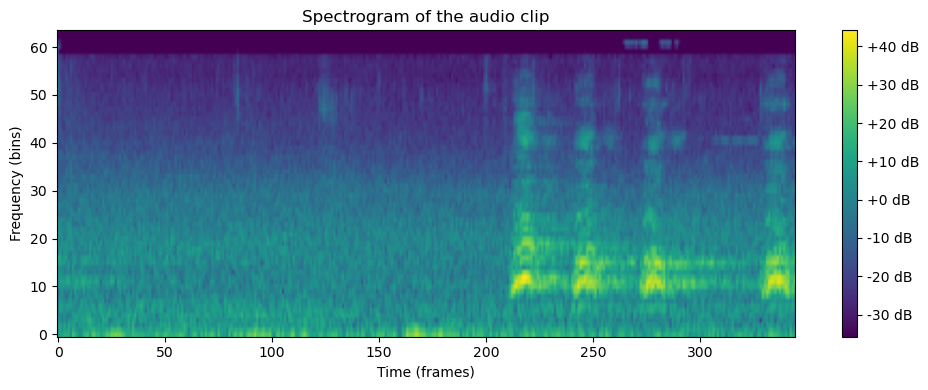

In [7]:
print(aud)
print(aud[0].shape)
print(f"Num channels = ", aud[0].shape[0])

if aud[0].shape[0] == 1:
    aud = AudioUtil.rechannel(aud, 2)
    print(f"Num channels now = ", aud[0].shape[0])

spec = AudioUtil.spectro_gram(aud)
show_spectrogram(spec, title="Spectrogram of the audio clip")

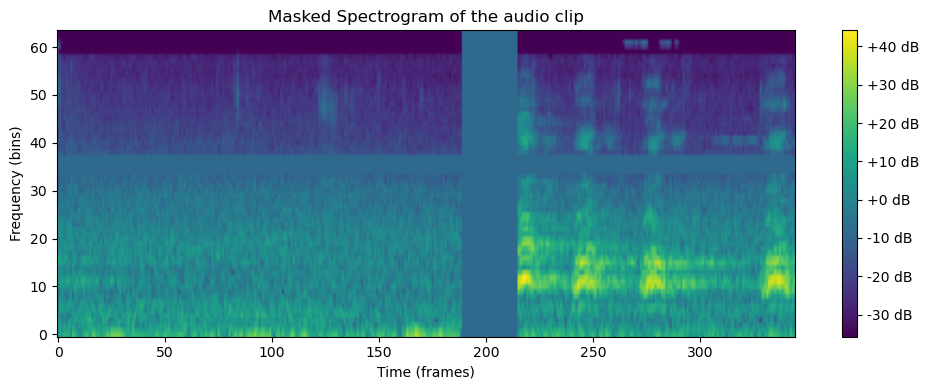

In [8]:
spec2 = AudioUtil.spectro_augment(spec, max_mask_pct=0.1, n_freq_masks=1, n_time_masks=1)
show_spectrogram(spec2, title="Masked Spectrogram of the audio clip")

In [9]:
from torch.utils.data import DataLoader, Dataset, random_split
import torchaudio

# ----------------------------
# Sound Dataset
# ----------------------------
class SoundDS(Dataset):
  def __init__(self, df, data_path):
    self.df = df
    self.data_path = str(data_path)
    self.duration = 4000
    self.sr = 44100
    self.channel = 2
    self.shift_pct = 0.4
            
  # ----------------------------
  # Number of items in dataset
  # ----------------------------
  def __len__(self):
    return len(self.df)    
    
  # ----------------------------
  # Get i'th item in dataset
  # ----------------------------
  def __getitem__(self, idx):
    # Absolute file path of the audio file - concatenate the audio directory with
    # the relative path
    audio_file = self.data_path + self.df.loc[idx, 'relative_path']
    # Get the Class ID
    class_id = self.df.loc[idx, 'classID']

    aud = AudioUtil.open(audio_file)
    # Some sounds have a higher sample rate, or fewer channels compared to the
    # majority. So make all sounds have the same number of channels and same 
    # sample rate. Unless the sample rate is the same, the pad_trunc will still
    # result in arrays of different lengths, even though the sound duration is
    # the same.
    reaud = AudioUtil.resample(aud, self.sr)
    rechan = AudioUtil.rechannel(reaud, self.channel)

    dur_aud = AudioUtil.pad_trunc(rechan, self.duration)
    shift_aud = AudioUtil.time_shift(dur_aud, self.shift_pct)
    sgram = AudioUtil.spectro_gram(shift_aud, n_mels=64, n_fft=1024, hop_len=None)
    aug_sgram = AudioUtil.spectro_augment(sgram, max_mask_pct=0.1, n_freq_masks=2, n_time_masks=2)

    return aug_sgram, class_id, idx

In [10]:
from torch.utils.data import random_split

data_audio_path = download_path + '/audio'
myds = SoundDS(df, data_audio_path)

# Random split of 80:20 between training and validation
num_items = len(myds)
num_train = round(num_items * 0.8)
num_val = num_items - num_train
train_ds, val_ds = random_split(myds, [num_train, num_val])

# Create training and validation data loaders
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl = torch.utils.data.DataLoader(val_ds, batch_size=16, shuffle=False)

Batch shape: torch.Size([16, 2, 64, 344]), Class IDs: tensor([0, 9, 4, 3, 5, 5, 0, 7, 9, 0, 3, 6, 1, 0, 8, 2]), 
original indices: tensor([3942, 1658, 8559, 4944, 3180, 3847, 3422,  378, 7256, 2897, 4824, 5104,
        7682, 4785, 7437, 3362])


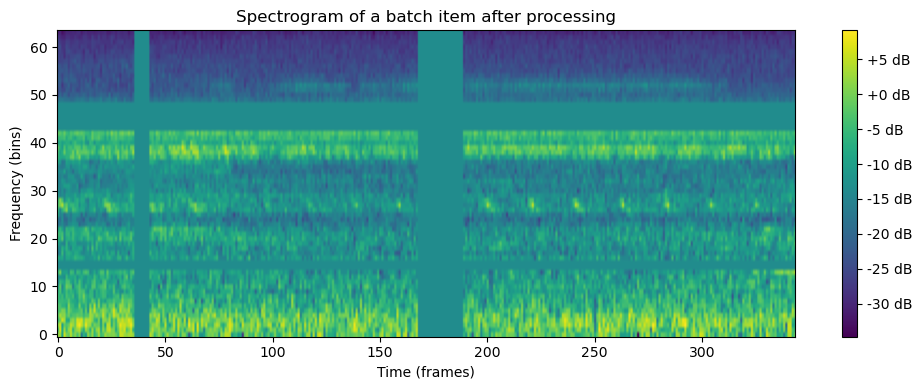

In [11]:
def debug(aud, orig_idx):
    show_spectrogram(aud, title="Spectrogram of a batch item after processing")
    audio_file = data_audio_path + df.loc[orig_idx, 'relative_path']
    aud, audio_sr = AudioUtil.open(audio_file)
    display(Audio(data=aud, rate=audio_sr))

for batch in train_dl:
    aud, class_id, orig_idx = batch
    print(f"Batch shape: {aud.shape}, Class IDs: {class_id}, \noriginal indices: {orig_idx}")
    batch_item, orig_idx = aud[0], orig_idx[0].item()
    debug(batch_item, orig_idx)
    break

In [12]:
import torch.nn.functional as F
from torch.nn import init

# ----------------------------
# Audio Classification Model
# ----------------------------
class AudioClassifier (nn.Module):
    # ----------------------------
    # Build the model architecture
    # ----------------------------
    def __init__(self):
        super().__init__()
        conv_layers = []

        # First Convolution Block with Relu and Batch Norm. Use Kaiming Initialization
        self.conv1 = nn.Conv2d(2, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
        self.relu1 = nn.ReLU()
        self.bn1 = nn.BatchNorm2d(8)
        init.kaiming_normal_(self.conv1.weight, a=0.1)
        self.conv1.bias.data.zero_()
        conv_layers += [self.conv1, self.relu1, self.bn1]

        # Second Convolution Block
        self.conv2 = nn.Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        self.relu2 = nn.ReLU()
        self.bn2 = nn.BatchNorm2d(16)
        init.kaiming_normal_(self.conv2.weight, a=0.1)
        self.conv2.bias.data.zero_()
        conv_layers += [self.conv2, self.relu2, self.bn2]

        # Second Convolution Block
        self.conv3 = nn.Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        self.relu3 = nn.ReLU()
        self.bn3 = nn.BatchNorm2d(32)
        init.kaiming_normal_(self.conv3.weight, a=0.1)
        self.conv3.bias.data.zero_()
        conv_layers += [self.conv3, self.relu3, self.bn3]

        # Second Convolution Block
        self.conv4 = nn.Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        self.relu4 = nn.ReLU()
        self.bn4 = nn.BatchNorm2d(64)
        init.kaiming_normal_(self.conv4.weight, a=0.1)
        self.conv4.bias.data.zero_()
        conv_layers += [self.conv4, self.relu4, self.bn4]

        # Linear Classifier
        self.ap = nn.AdaptiveAvgPool2d(output_size=1)
        self.lin = nn.Linear(in_features=64, out_features=10)

        # Wrap the Convolutional Blocks
        self.conv = nn.Sequential(*conv_layers)
 
    # ----------------------------
    # Forward pass computations
    # ----------------------------
    def forward(self, x):
        # Run the convolutional blocks
        x = self.conv(x)

        # Adaptive pool and flatten for input to linear layer
        x = self.ap(x)
        x = x.view(x.shape[0], -1)

        # Linear layer
        x = self.lin(x)

        # Final output
        return x

# Create the model and put it on the GPU if available
myModel = AudioClassifier()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
myModel = myModel.to(device)
# Check that it is on Cuda
next(myModel.parameters()).device

print(myModel)

AudioClassifier(
  (conv1): Conv2d(2, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (relu1): ReLU()
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (relu2): ReLU()
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (relu3): ReLU()
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (relu4): ReLU()
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (ap): AdaptiveAvgPool2d(output_size=1)
  (lin): Linear(in_features=64, out_features=10, bias=True)
  (conv): Sequential(
    (0): Conv2d(2, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(8, eps=1e-05, mome

In [13]:
from tqdm import tqdm

# ----------------------------
# Training Loop
# ----------------------------
def training(model, train_dl, num_epochs):
  # Loss Function, Optimizer and Scheduler
  criterion = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
  scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.001,
                                                steps_per_epoch=int(len(train_dl)),
                                                epochs=num_epochs,
                                                anneal_strategy='linear')

  # Repeat for each epoch
  for epoch in range(num_epochs):
    running_loss = 0.0
    correct_prediction = 0
    total_prediction = 0

    # Repeat for each batch in the training set
    for i, data in enumerate(tqdm(train_dl, desc=f"Epoch {epoch+1}")):
        # Get the input features and target labels, and put them on the GPU
        inputs, labels = data[0].to(device), data[1].to(device)

        # Normalize the inputs
        inputs_m, inputs_s = inputs.mean(), inputs.std()
        inputs = (inputs - inputs_m) / inputs_s

        # Zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Keep stats for Loss and Accuracy
        running_loss += loss.item()

        # Get the predicted class with the highest score
        _, prediction = torch.max(outputs,1)
        # Count of predictions that matched the target label
        correct_prediction += (prediction == labels).sum().item()
        total_prediction += prediction.shape[0]
    
    # Print stats at the end of the epoch
    num_batches = len(train_dl)
    avg_loss = running_loss / num_batches
    acc = correct_prediction/total_prediction
    print(f'Epoch: {epoch}, Loss: {avg_loss:.2f}, Accuracy: {acc:.2f}')

  print('Finished Training')
  
num_epochs=15   # Just for demo, adjust this higher.
training(myModel, train_dl, num_epochs)

Epoch 1:   4%|▍         | 17/437 [00:02<01:13,  5.70it/s]


KeyboardInterrupt: 

In [ ]:
# ----------------------------
# Inference
# ----------------------------
def inference (model, val_dl):
  correct_prediction = 0
  total_prediction = 0

  # Disable gradient updates
  with torch.no_grad():
    for data in val_dl:
      # Get the input features and target labels, and put them on the GPU
      inputs, labels = data[0].to(device), data[1].to(device)

      # Normalize the inputs
      inputs_m, inputs_s = inputs.mean(), inputs.std()
      inputs = (inputs - inputs_m) / inputs_s

      # Get predictions
      outputs = model(inputs)

      # Get the predicted class with the highest score
      _, prediction = torch.max(outputs,1)
      # Count of predictions that matched the target label
      correct_prediction += (prediction == labels).sum().item()
      total_prediction += prediction.shape[0]
    
  acc = correct_prediction/total_prediction
  print(f'Accuracy: {acc:.2f}, Total items: {total_prediction}')

# Run inference on trained model with the validation set
inference(myModel, val_dl)

Accuracy: 0.75, Total items: 1746


In [ ]:
def debug(aud, orig_idx):
    show_spectrogram(aud, title="Spectrogram of a batch item after processing")
    audio_file = data_audio_path + df.loc[orig_idx, 'relative_path']
    aud, audio_sr = AudioUtil.open(audio_file)
    display(Audio(data=aud, rate=audio_sr))

Sample 1: Predicted: [5 5 1 6 5 5 5 5 5 1 5 5 5 1 5 5], Actual: [3 0 2 4 0 2 4 9 4 8 2 7 5 2 5 0]
engine_idling Actual: drilling


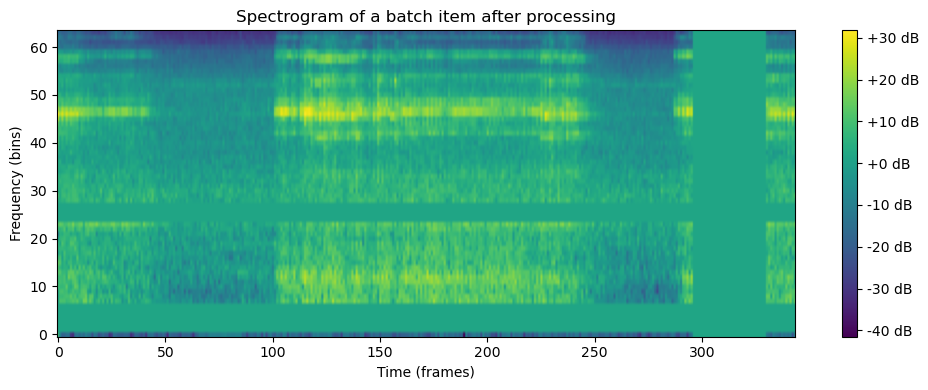

engine_idling Actual: air_conditioner


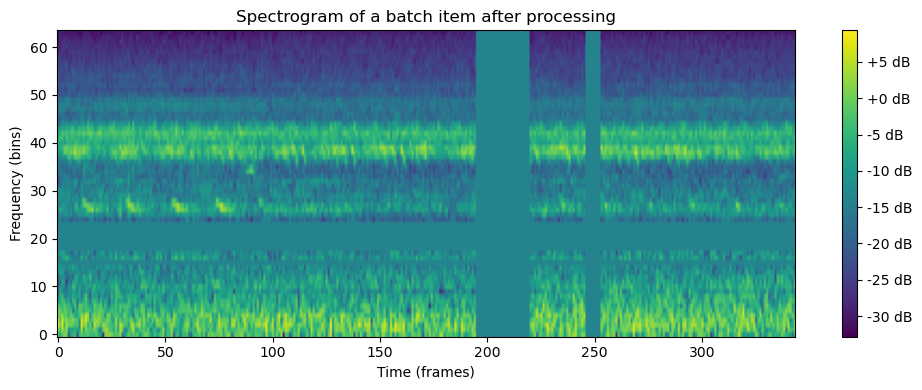

gun_shot Actual: drilling


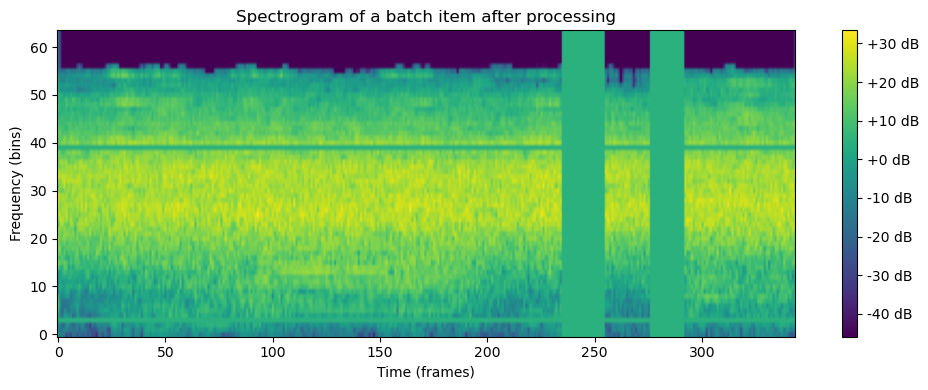

engine_idling Actual: jackhammer


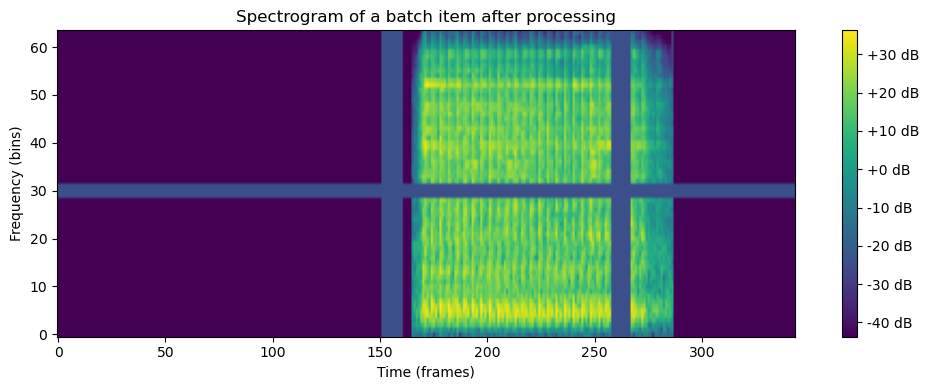

engine_idling Actual: engine_idling


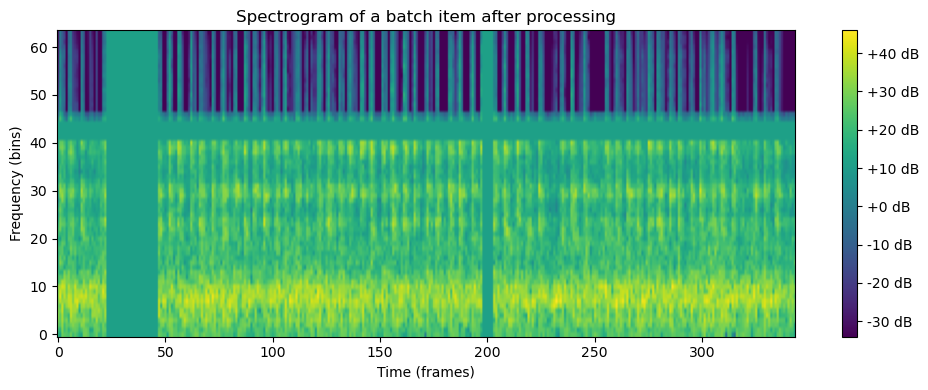

In [ ]:
def draw_samples(model, val_dl, num_samples=5):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for i, data in enumerate(val_dl):
            inputs, labels, actual_audio_idx = data[0].to(device), data[1].to(device), data[2]
            outputs = model(inputs)
            _, predictions = torch.max(outputs, 1)
            predictions_class = [index_to_class[p.item()] for p in predictions]
            print(f"Sample {i+1}: Predicted: {predictions.cpu().numpy()}, Actual: {labels.cpu().numpy()}")

            idxs = np.random.choice(inputs.shape[0], size=min(8, inputs.shape[0]), replace=False)
            for j in idxs:
                print(predictions_class[j], "Actual:", index_to_class[labels[j].item()])
                debug(inputs[j].cpu(), actual_audio_idx[j].item())
            break

draw_samples(myModel, val_dl, num_samples=5)